# 粒子群优化算法（Particle Swarm Optimization, PSO）

粒子群优化算法是一种典型的群智能优化算法，最早受到鸟群觅食、鱼群游动等群体行为启发。它常用于求解连续变量优化问题，尤其适合目标函数复杂、不可导、非凸、多峰的问题。

PSO 的核心思想很直观：

- 每个候选解看作一个“粒子”；
- 粒子在搜索空间中移动；
- 每个粒子记住自己历史上找到的最好位置；
- 整个群体共享目前找到的最好位置；
- 粒子下一步怎么飞，由“惯性”“自身经验”“群体经验”共同决定。


## 1. 优化问题形式

以最小化问题为例，PSO 试图求解：

$$
\min_{x \in \Omega} f(x)
$$

其中：

- $x = (x_1, x_2, \dots, x_d)$ 表示一个 $d$ 维决策变量；
- $f(x)$ 是目标函数；
- $\Omega$ 是搜索空间，也就是变量取值范围。

在数学建模中，PSO 可以用来处理参数寻优、路径规划、函数拟合、模型校准、组合优化的连续化近似等问题。

## 2. 粒子的状态

第 $i$ 个粒子在第 $t$ 次迭代时有两个核心状态：

- 位置：$x_i^t$，表示当前候选解；
- 速度：$v_i^t$，表示下一步移动方向和步长。

此外，每个粒子还会记录：

- 个体历史最优位置：$p_i^t$，也叫 `pbest`；
- 全局历史最优位置：$g^t$，也叫 `gbest`。

## 3. 更新公式

PSO 每轮迭代主要做两件事：更新速度、更新位置。

速度更新公式：

$$
v_i^{t+1} = wv_i^t + c_1 r_1(p_i^t - x_i^t) + c_2 r_2(g^t - x_i^t)
$$

位置更新公式：

$$
x_i^{t+1} = x_i^t + v_i^{t+1}
$$

参数含义：

- $w$：惯性权重，控制粒子保留原速度的程度；
- $c_1$：个体学习因子，控制粒子向自己历史最优位置靠近的程度；
- $c_2$：社会学习因子，控制粒子向全局最优位置靠近的程度；
- $r_1, r_2$：$[0,1]$ 上的随机数，用来增加搜索随机性。


## 4. 算法流程

PSO 的基本流程如下：

1. 初始化粒子群的位置和速度。
2. 计算每个粒子的目标函数值。
3. 初始化每个粒子的个体最优 `pbest`。
4. 初始化全局最优 `gbest`。
5. 重复迭代：
   - 根据公式更新速度；
   - 根据速度更新位置；
   - 对越界位置进行处理；
   - 重新计算适应度；
   - 更新 `pbest` 和 `gbest`。
6. 达到最大迭代次数或满足收敛条件后，输出全局最优解。


In [1]:
import numpy as np

try:
    import matplotlib.pyplot as plt
    plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
    plt.rcParams["axes.unicode_minus"] = False
except ModuleNotFoundError:
    plt = None
    print("当前环境没有安装 matplotlib，绘图单元会跳过。可运行：pip install matplotlib")


## 5. 从零实现 PSO

下面实现一个通用的最小化版本 PSO。输入包括目标函数、变量边界、粒子数、迭代次数等。

In [2]:
def pso_minimize(
    func,
    bounds,
    n_particles=40,
    max_iter=200,
    w=0.7,
    c1=1.5,
    c2=1.5,
    seed=42,
):
    """使用粒子群优化算法最小化目标函数。

    Parameters
    ----------
    func : callable
        目标函数，输入形如 (n_particles, dim) 的二维数组，返回每个粒子的函数值。
    bounds : list[tuple[float, float]]
        每个变量的上下界，例如 [(-5, 5), (-5, 5)]。
    n_particles : int
        粒子数量。
    max_iter : int
        最大迭代次数。
    w, c1, c2 : float
        惯性权重、个体学习因子、社会学习因子。
    seed : int
        随机种子，便于复现实验。
    """
    rng = np.random.default_rng(seed)
    bounds = np.asarray(bounds, dtype=float)
    lower = bounds[:, 0]
    upper = bounds[:, 1]
    dim = len(bounds)

    positions = rng.uniform(lower, upper, size=(n_particles, dim))
    velocity_limit = upper - lower
    velocities = rng.uniform(-velocity_limit, velocity_limit, size=(n_particles, dim)) * 0.1

    fitness = func(positions)
    personal_best_positions = positions.copy()
    personal_best_values = fitness.copy()

    best_index = np.argmin(personal_best_values)
    global_best_position = personal_best_positions[best_index].copy()
    global_best_value = personal_best_values[best_index]

    history = [global_best_value]

    for _ in range(max_iter):
        r1 = rng.random(size=(n_particles, dim))
        r2 = rng.random(size=(n_particles, dim))

        cognitive = c1 * r1 * (personal_best_positions - positions)
        social = c2 * r2 * (global_best_position - positions)
        velocities = w * velocities + cognitive + social
        positions = positions + velocities

        positions = np.clip(positions, lower, upper)

        fitness = func(positions)
        improved = fitness < personal_best_values
        personal_best_positions[improved] = positions[improved]
        personal_best_values[improved] = fitness[improved]

        best_index = np.argmin(personal_best_values)
        if personal_best_values[best_index] < global_best_value:
            global_best_value = personal_best_values[best_index]
            global_best_position = personal_best_positions[best_index].copy()

        history.append(global_best_value)

    return global_best_position, global_best_value, np.array(history)


## 6. 示例一：Sphere 函数

Sphere 函数是最常见的测试函数之一：

$$
f(x) = \sum_{j=1}^{d} x_j^2
$$

它的全局最优解为 $x=(0,0,\dots,0)$，最优值为 $0$。  
由于数值解计算浮点精度的问题，其最终结果应该为一个不为零的非常小的数  

In [3]:
def sphere(x):
    return np.sum(x ** 2, axis=1)


best_x, best_y, history = pso_minimize(
    sphere,
    bounds=[(-5, 5), (-5, 5)],
    n_particles=40,
    max_iter=120,
    seed=1,
)

print("最优位置：", best_x)
print("最优函数值：", best_y)


最优位置： [-4.76226928e-09 -2.75686635e-08]
最优函数值： 7.827104149906759e-16


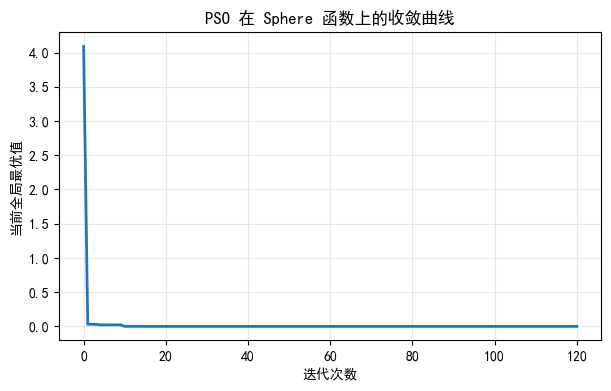

In [4]:
if plt is None:
    print("跳过绘图：请先安装 matplotlib。")
else:
    plt.figure(figsize=(7, 4))
    plt.plot(history, linewidth=2)
    plt.xlabel("迭代次数")
    plt.ylabel("当前全局最优值")
    plt.title("PSO 在 Sphere 函数上的收敛曲线")
    plt.grid(alpha=0.3)
    plt.show()


## 7. 示例二：Rastrigin 函数

Rastrigin 函数是一个典型的多峰函数：

$$
f(x) = 10d + \sum_{j=1}^{d}\left[x_j^2 - 10\cos(2\pi x_j)\right]
$$

它有很多局部最优点，因此比 Sphere 函数更能体现群智能算法的全局搜索能力。全局最优解仍为 $x=(0,0,\dots,0)$，最优值为 $0$。

In [5]:
def rastrigin(x):
    dim = x.shape[1]
    return 10 * dim + np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x), axis=1)


best_x, best_y, history = pso_minimize(
    rastrigin,
    bounds=[(-5.12, 5.12), (-5.12, 5.12)],
    n_particles=60,
    max_iter=250,
    w=0.72,
    c1=1.49,
    c2=1.49,
    seed=2,
)

print("最优位置：", best_x)
print("最优函数值：", best_y)


最优位置： [-1.11915149e-09  3.53899915e-09]
最优函数值： 0.0


## 8. 参数如何理解

PSO 参数会明显影响搜索行为。

| 参数 | 常见取值 | 作用 | 过大可能导致 | 过小可能导致 |
| --- | --- | --- | --- | --- |
| 粒子数 `n_particles` | 20 到 100 | 控制搜索覆盖范围 | 计算量增加 | 搜索不充分 |
| 迭代次数 `max_iter` | 100 到 1000 | 控制搜索时间 | 耗时增加 | 尚未收敛 |
| 惯性权重 `w` | 0.4 到 0.9 | 平衡全局搜索和局部搜索 | 粒子震荡 | 容易早熟收敛 |
| 个体学习因子 `c1` | 1 到 2 | 强调自身经验 | 搜索分散 | 个体探索不足 |
| 社会学习因子 `c2` | 1 到 2 | 强调群体经验 | 过快聚集 | 协同能力不足 |

经验设置：

- 初学或一般问题可先用 `w=0.7, c1=1.5, c2=1.5`；
- 多峰函数可适当增加粒子数；
- 若发现很快停在较差结果，可增大 `w` 或粒子数；
- 若后期收敛慢，可减小 `w`，加强局部搜索。

## 9. 常见改进思路

基础 PSO 简单好用，但也容易早熟收敛。常见改进包括：

- 线性递减惯性权重：前期大 $w$ 做全局探索，后期小 $w$ 做局部开发；
- 限制最大速度：避免粒子一步飞太远；
- 局部邻域最优：用邻域最优代替全局最优，增强多样性；
- 混合算法：PSO 与遗传算法、模拟退火、局部搜索结合；
- 约束处理：对不可行解使用罚函数、修复函数或可行性规则。

## 10. 数学建模中的使用步骤

在建模题中使用 PSO，可以按下面的顺序组织：

1. 明确决策变量：确定每个粒子的位置向量代表什么。
2. 构造目标函数：把题目要求转化为可计算的 $f(x)$。
3. 确定约束条件：给出变量上下界和其他约束。
4. 设计适应度函数：若有约束，可加入罚函数。
5. 设置 PSO 参数：粒子数、迭代次数、$w,c_1,c_2$。
6. 运行多次实验：随机算法有波动，建议多次运行取较好结果或平均结果。
7. 分析结果：报告最优解、目标函数值、收敛曲线和参数敏感性。


## 11. 小结

PSO 的优点：

- 原理简单，代码实现短；
- 不要求目标函数可导；
- 对非线性、非凸、多峰问题有一定全局搜索能力；
- 很适合数学建模中的参数优化问题。

PSO 的缺点：

- 参数设置会影响结果；
- 可能早熟收敛；
- 高维问题中搜索效率可能下降；
- 对复杂约束需要额外设计处理方法。

一句话记忆：PSO 是一群候选解在搜索空间中“边飞边学”，既参考自己的最好经验，也参考群体目前找到的最好经验。